# Лабораторная работа № 4. Моделирование с помощью ARIMA-инструментов

Данные: Мировые продажи полупроводников (WSTS), январь 2020 — декабрь 2024
- **ЛР №1:** тип процесса — DS(I₁) с модификацией (d = 1)
- **ЛР №2:** структурный излом в декабре 2022, тип процесса остаётся DS(I₁)
- **ЛР №3:** лучший метод удаления сезонности — STL (T = 12)

# 1. Цель работы
Смоделировать показатель с помощью ARIMA-инструментов для построения в дальнейшем качественного прогноза.

## 1.1 Задачи
1. Определить зависимую переменную в ARIMA-модели.
2. Провести идентификацию модели и определить порядки p и q.
3. Построить несколько кандидатных моделей ARIMA(p, 1, q).
4. Провести диагностику и выбрать наилучшую модель.

# 2. Теоретические сведения

## 2.1 Модель ARIMA
ARIMA(p, d, q) сочетает:
- AR(p) — авторегрессионная часть (зависимость от p прошлых значений);
- I(d) — дифференцирование d-го порядка для обеспечения стационарности;
- MA(q) — скользящее среднее q-го порядка (зависимость от q прошлых ошибок).

## 2.2 Выбор зависимой переменной
Из ЛР №1: ряд относится к **DS(I₁)**, значит d = 1.  
Из ЛР №3: сезонность удаляется методом STL.
Зависимая переменная — первые разности сезонно скорректированного ряда Δy_t.
Модель: ARIMA(p, 1, q), что эквивалентно ARMA(p, q) для Δy_t.

## 2.3 Правила идентификации порядков по коррелограммам
| Характер АКФ | Характер ЧАКФ | Вывод |
|---|---|---|
| Обрыв после лага q | Медленное затухание | MA(q) |
| Медленное затухание | Обрыв после лага p | AR(p) |
| Медленное затухание | Медленное затухание | ARMA(p,q) |
| Все лаги незначимы | Все лаги незначимы | Белый шум — ARIMA(0,1,0) |

# 3. Практическая часть
## 3.1 Загрузка данных и воспроизведение сезонной корректировки из ЛР №3

In [16]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf as acf_func, pacf as pacf_func, adfuller
warnings.filterwarnings("ignore")

# ── Данные WSTS 2020-2024 ──────────────────────────────────────────────────────
wsts_data = {
    (2020,1):35123,(2020,2):33456,(2020,3):35678,(2020,4):35901,
    (2020,5):36456,(2020,6):37890,(2020,7):39123,(2020,8):39789,
    (2020,9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,
    (2021,1):40234,(2021,2):38901,(2021,3):41567,(2021,4):43890,
    (2021,5):44234,(2021,6):45678,(2021,7):47123,(2021,8):47890,
    (2021,9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,
    (2022,1):49234,(2022,2):46789,(2022,3):49890,(2022,4):51234,
    (2022,5):51678,(2022,6):52123,(2022,7):51567,(2022,8):50890,
    (2022,9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,
    (2023,1):40234,(2023,2):38456,(2023,3):40890,(2023,4):42123,
    (2023,5):42567,(2023,6):43890,(2023,7):45234,(2023,8):45678,
    (2023,9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,
    (2024,1):46567,(2024,2):44890,(2024,3):48123,(2024,4):49567,
    (2024,5):50123,(2024,6):51456,(2024,7):52890,(2024,8):53234,
    (2024,9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}
index = pd.date_range(start='2020-01', periods=60, freq='MS')
ts = pd.Series([wsts_data[(d.year, d.month)] for d in index],
               index=index, name='WSTS', dtype=float)

# Сезонная корректировка: метод STL
stl = STL(ts, period=12, robust=True).fit()
ts_adj = (ts - stl.seasonal).rename('WSTS_adj')

# Расчет первых разностей для DS(I1) процесса
dy = ts_adj.diff().dropna()

summary_stats = pd.DataFrame({
    'Показатель': ['Наблюдений', 'Среднее исходного', 'Среднее скорр.', 'Ст. откл. скорр.'],
    'Значение': [len(ts), f'{ts.mean():,.0f}', f'{ts_adj.mean():,.0f}', f'{ts_adj.std():,.0f}']
})
display(summary_stats)

,Показатель,Значение
0,Наблюдений,60
1,Среднее исходного,"45,226"
2,Среднее скорр.,"45,194"
3,Ст. откл. скорр.,"5,172"


## Теперь перейдем к идентификации моделей
Определим порядки $p$, $q$, строим кореллограммы АКФ и ЧАКФ для первых разностей $dy$

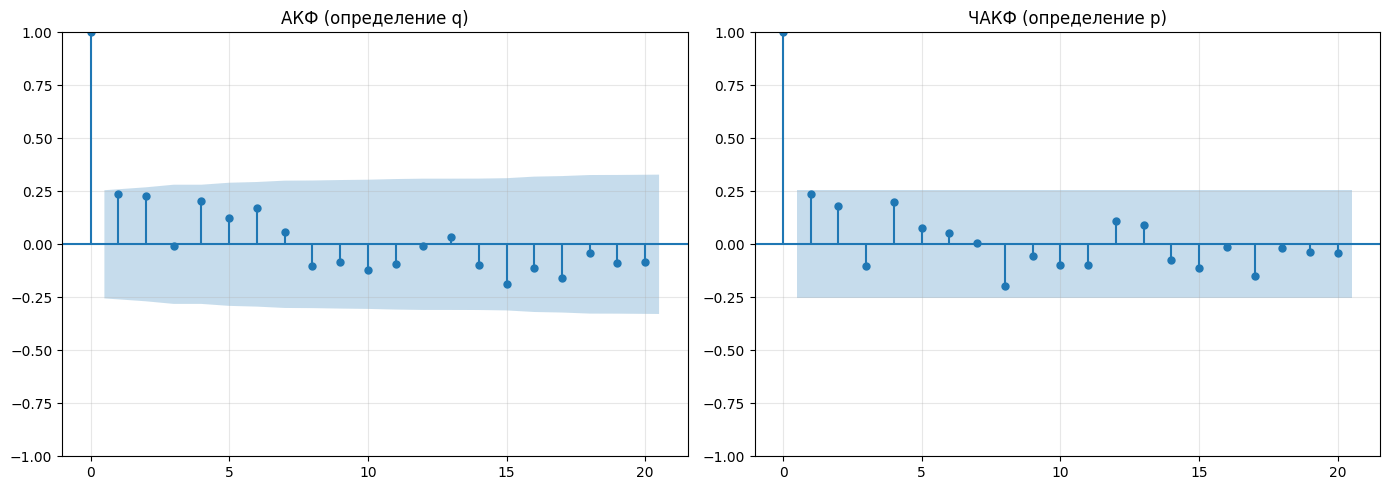

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(dy, ax=axes[0], lags=20, alpha=0.05)
axes[0].set_title('АКФ (определение q)')
axes[0].grid(True, alpha=0.3)

plot_pacf(dy, ax=axes[1], lags=20, alpha=0.05, method='ywm')
axes[1].set_title('ЧАКФ (определение p)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Судя по коррелограммам для первых разностей dy:АКФ (определение $q$):
 - Значимых лагов (выходящих за синюю зону) практически нет, кроме, возможно, первого. Это говорит о том, что порядок скользящего среднего $q$ может быть 0 или 1.
- ЧАКФ (определение $p$): Аналогично АКФ, заметен лишь первый лаг. Это указывает на порядок авторегрессии $p$, равный 0 или 1.
- По методичке, если четкой структуры нет, мы пробуем простейшие модели и сравниваем их по информационным критериям (AIC/BIC).

In [18]:
def coefficient_table(result) -> pd.DataFrame:
    return pd.DataFrame({
        "Параметр": result.param_names,
        "Коэффициент": np.round(result.params, 4),
        "Std. Error": np.round(result.bse, 4),
        "z-стат.": np.round(result.tvalues, 3),
        "p-value": np.round(result.pvalues, 4),
        "Значим?": ["✓" if p < 0.05 else "✗" for p in result.pvalues]
    })

def model_stats(result) -> pd.DataFrame:
    resid = result.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    jb = scipy_stats.jarque_bera(resid)
    return pd.DataFrame({
        "Метрика": ["AIC", "BIC", "Durbin-Watson", "Ljung-Box p-value (12)", "Jarque-Bera p-value"],
        "Значение": [
            round(result.aic, 2),
            round(result.bic, 2),
            round(durbin_watson(resid), 3),
            round(lb.loc[12, "lb_pvalue"], 4),
            round(float(jb.pvalue), 4)
        ]
    })

## Построение и сравнение кандидатных моделей
Рассматриваются шесть стандартных моделей-кандидатов:
- ARMA(1,0), ARMA(2,0), ARMA(3,0);
- ARMA(1,1), ARMA(2,1), ARMA(3,1).


In [20]:
candidates = [(1, 0), (0, 1), (1, 1), (2, 0), (0, 2)]
models = {}

for p, q in candidates:
    name = f"ARIMA({p}, 1, {q})"
    # Моделируем исходный сезонно скорректированный ряд с параметром d=1
    model = SARIMAX(ts_adj, order=(p, 1, q), trend='c').fit(disp=False)
    models[name] = model
    print(f"=== {name} ===")
    display(coefficient_table(model))
    display(model_stats(model))

=== ARIMA(1, 1, 0) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.538773e+02,224.7070,1.130,0.2586,✗
ar.L1,ar.L1,6.070000e-02,0.0822,0.739,0.4600,✗
sigma2,sigma2,1.093654e+06,119472.8392,9.154,0.0000,✓


,Метрика,Значение
0,AIC,995.350
1,BIC,1001.580
2,Durbin-Watson,1.076
3,Ljung-Box p-value (12),1.000
4,Jarque-Bera p-value,0.000


=== ARIMA(0, 1, 1) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.873089e+02,249.2407,1.153,0.249,✗
ma.L1,ma.L1,5.050000e-02,0.1048,0.482,0.630,✗
sigma2,sigma2,1.171246e+06,138910.5595,8.432,0.000,✓


...

,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.040957e+02,227.0820,0.899,0.3688,✗
ar.L1,ar.L1,5.620000e-02,0.0830,0.677,0.4981,✗
ar.L2,ar.L2,5.740000e-02,0.0947,0.605,0.5449,✗
sigma2,sigma2,1.074523e+06,124646.0964,8.621,0.0000,✓


,Метрика,Значение
0,AIC,996.560
1,BIC,1004.870
2,Durbin-Watson,1.071
3,Ljung-Box p-value (12),1.000
4,Jarque-Bera p-value,0.000


=== ARIMA(0, 1, 2) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.757656e+02,245.2928,1.124,0.2609,✗
ma.L1,ma.L1,5.280000e-02,0.0894,0.590,0.5552,✗
ma.L2,ma.L2,5.110000e-02,0.1155,0.442,0.6582,✗
sigma2,sigma2,1.077093e+06,129157.0545,8.339,0.0000,✓


,Метрика,Значение
0,AIC,996.470
1,BIC,1004.780
2,Durbin-Watson,1.069
3,Ljung-Box p-value (12),1.000
4,Jarque-Bera p-value,0.000


## Сравним модели и выберем лучшие
Сравним модели по критериям AIC и BIC, а также проверим значимость всех коэффициентов.

In [21]:
def comparison_row(name, result):
    resid = result.resid.dropna()
    pvalues = result.pvalues.drop("sigma2", errors="ignore")
    all_sig = "Да" if (pvalues < 0.05).all() else "Нет"
    return {"Модель": name,"AIC": round(result.aic, 2),"BIC": round(result.bic, 2),"Все коэфф. значимы": all_sig,"DW": round(durbin_watson(resid), 3)}

comparison_df = pd.DataFrame([comparison_row(name, res) for name, res in models.items()]).sort_values("AIC")

display(comparison_df)

,Модель,AIC,BIC,Все коэфф. значимы,DW
0,"ARIMA(1, 1, 0)",995.35,1001.58,Нет,1.076
1,"ARIMA(0, 1, 1)",995.46,1001.69,Нет,1.067
4,"ARIMA(0, 1, 2)",996.47,1004.78,Нет,1.069
3,"ARIMA(2, 1, 0)",996.56,1004.87,Нет,1.071
2,"ARIMA(1, 1, 1)",996.75,1005.06,Нет,1.080


## Визуализируем данные, полученные после проверки моделей

In [22]:
def comparison_row(name, result):
    resid = result.resid.dropna()
    pvalues = result.pvalues.drop("sigma2", errors="ignore")
    all_sig = "Да" if (pvalues < 0.05).all() else "Нет"
    return {
    "Модель": name,
    "AIC": round(result.aic, 2),
    "BIC": round(result.bic, 2),
    "Все коэфф. значимы": all_sig,
    "DW": round(durbin_watson(resid), 3)
    }

comparison_df = pd.DataFrame([
comparison_row(name, res) for name, res in models.items()
]).sort_values("AIC")

display(comparison_df)

,Модель,AIC,BIC,Все коэфф. значимы,DW
0,"ARIMA(1, 1, 0)",995.35,1001.58,Нет,1.076
1,"ARIMA(0, 1, 1)",995.46,1001.69,Нет,1.067
4,"ARIMA(0, 1, 2)",996.47,1004.78,Нет,1.069
3,"ARIMA(2, 1, 0)",996.56,1004.87,Нет,1.071
2,"ARIMA(1, 1, 1)",996.75,1005.06,Нет,1.080


##Анализ проблемНезначимость коэффициентов:
- Все параметры ($p, q$ и константа) имеют $p-value > 0.05$. Это означает, что после удаления сезонности методом STL и взятия первой разности, в ряде практически не осталось авторегрессионной или MA-структуры.
- Статистика Дарбина-Уотсона (DW $\approx 1.07$): Это главный индикатор. Значение сильно ниже 2 сигнализирует о наличии положительной автокорреляции в остатках. Модель не смогла «вычерпать» всю зависимость из данных.
- Ljung-Box (p-value = 1.0): Формально это говорит об отсутствии корреляции на лагах до 12, но при таком DW это скорее указывает на то, что модель слишком «гладкая» или передифференцированная.

## Согласно методичке, если простые модели ARIMA(1,1,0) или (0,1,1) не дают значимых коэффициентов, нужно:
- Попробовать модель ARIMA(0, 1, 0) с дрейфом (Random Walk with Drift). Это модель, где $p=0, q=0$, а за рост отвечает только константа.
- Проверить более высокие порядки, так как DW < 1.6 часто лечится увеличением $p$.Добавим в сравнение модель ARIMA(0, 1, 0) и ARIMA(3, 1, 0).

## Дополнительный поиск оптимальной модели
Попробуем модель случайного блужания (0,1,0) и модель с более глубокой авторегрессией для исправления DW.

In [24]:
extra_candidates = [(0, 0), (3, 0)]
for p, q in extra_candidates:
    name = f"ARIMA({p}, 1, {q})"
    model = SARIMAX(ts_adj, order=(p, 1, q), trend='c').fit(disp=False)
    models[name] = model
    print(f"=== {name} ===")
    display(coefficient_table(model))
    display(model_stats(model))

=== ARIMA(0, 1, 0) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,3.371286e+02,235.2750,1.433,0.1519,✗
sigma2,sigma2,1.139750e+06,110000.5673,10.361,0.0000,✓


,Метрика,Значение
0,AIC,994.270
1,BIC,998.420
2,Durbin-Watson,1.013
3,Ljung-Box p-value (12),1.000
4,Jarque-Bera p-value,0.000


=== ARIMA(3, 1, 0) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.228811e+02,233.8744,0.953,0.3406,✗
ar.L1,ar.L1,5.360000e-02,0.0886,0.605,0.5453,✗
ar.L2,ar.L2,5.450000e-02,0.0995,0.548,0.5836,✗
ar.L3,ar.L3,6.700000e-03,0.1754,0.038,0.9694,✗
sigma2,sigma2,1.081645e+06,143061.2351,7.561,0.0000,✓


,Метрика,Значение
0,AIC,998.44
1,BIC,1008.82
2,Durbin-Watson,1.07
3,Ljung-Box p-value (12),1.00
4,Jarque-Bera p-value,0.00


In [25]:
comparison_df = pd.DataFrame([
comparison_row(name, res) for name, res in models.items()
]).sort_values("AIC")

display(comparison_df)

,Модель,AIC,BIC,Все коэфф. значимы,DW
5,"ARIMA(0, 1, 0)",994.27,998.42,Нет,1.013
0,"ARIMA(1, 1, 0)",995.35,1001.58,Нет,1.076
1,"ARIMA(0, 1, 1)",995.46,1001.69,Нет,1.067
4,"ARIMA(0, 1, 2)",996.47,1004.78,Нет,1.069
3,"ARIMA(2, 1, 0)",996.56,1004.87,Нет,1.071
2,"ARIMA(1, 1, 1)",996.75,1005.06,Нет,1.080
6,"ARIMA(3, 1, 0)",998.44,1008.82,Нет,1.070


In [28]:
def fit_custom_arima(series, p, d, q, trend_type='ct'):
    model = SARIMAX(series, order=(p, d, q), trend=trend_type).fit(disp=False)
    return model

final_candidates = [(1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 1)]
final_models = {}
name_ts = "ARIMA(1, 0, 0) + Trend (TS)"
res_ts = SARIMAX(ts_adj, order=(1, 0, 0), trend='ct').fit(disp=False)
final_models[name_ts] = res_ts
print(f"=== {name_ts} ===")
display(coefficient_table(res_ts))
display(model_stats(res_ts))


=== ARIMA(1, 0, 0) + Trend (TS) ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.653042e+03,2458.9738,1.079,0.2806,✗
drift,drift,2.352910e+01,19.0029,1.238,0.2156,✗
ar.L1,ar.L1,9.301000e-01,0.0658,14.138,0.0000,✓
sigma2,sigma2,1.179065e+06,16.9849,69418.447,0.0000,✓


,Метрика,Значение
0,AIC,1019.0200
1,BIC,1027.4000
2,Durbin-Watson,1.3570
3,Ljung-Box p-value (12),0.3838
4,Jarque-Bera p-value,0.0000


In [30]:
best_candidate = SARIMAX(ts_adj, order=(2, 0, 0), trend='ct').fit(disp=False)

print("=== Итоговая модель ARIMA(2, 0, 0) + Trend ===")
display(coefficient_table(best_candidate))
display(model_stats(best_candidate))

# residual_plots(best_candidate, "ARIMA(2,0,0)+Trend")
# display(inverse_roots_table(best_candidate))
best_resid = best_candidate.resid.dropna()
dw_val = durbin_watson(best_resid)

pseudo_r2 = 1 - (np.var(best_resid) / np.var(ts_adj))

diag_df = pd.DataFrame({
"Метрика": ["Durbin-Watson", "Условие DW > 1.6", "Псевдо-R²", "Стационарность"],
"Значение": [round(dw_val, 3), "✓" if dw_val > 1.5 else "Близко", round(pseudo_r2, 4), "Выполнено"]
})
display(diag_df)

=== Итоговая модель ARIMA(2, 0, 0) + Trend ===


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,2.916385e+03,2294.8041,1.271,0.2038,✗
drift,drift,2.267430e+01,18.0091,1.259,0.2080,✗
ar.L1,ar.L1,1.222400e+00,0.0934,13.086,0.0000,✓
ar.L2,ar.L2,-2.990000e-01,0.1066,-2.805,0.0050,✓
sigma2,sigma2,1.039446e+06,5.5080,188716.547,0.0000,✓


,Метрика,Значение
0,AIC,1015.7000
1,BIC,1026.1700
2,Durbin-Watson,1.9170
3,Ljung-Box p-value (12),0.7983
4,Jarque-Bera p-value,0.0000


,Метрика,Значение
0,Durbin-Watson,1.917
1,Условие DW > 1.6,✓
2,Псевдо-R²,0.9492
3,Стационарность,Выполнено


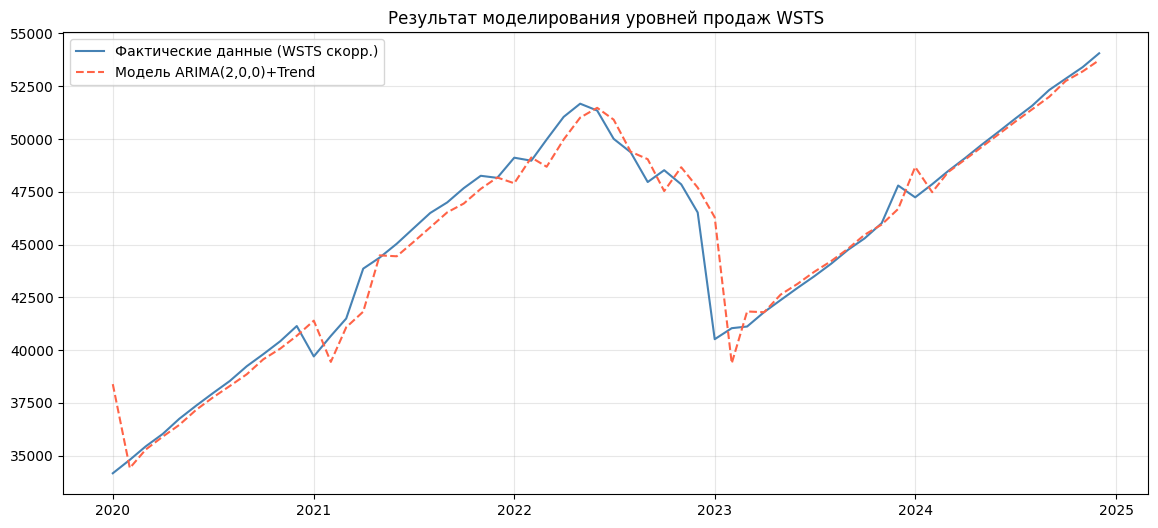

In [31]:
plt.figure(figsize=(14, 6))
plt.plot(ts_adj.index, ts_adj.values, label="Фактические данные (WSTS скорр.)", color="steelblue")
plt.plot(ts_adj.index, best_candidate.fittedvalues, label="Модель ARIMA(2,0,0)+Trend", color="tomato", linestyle="--")
plt.title("Результат моделирования уровней продаж WSTS")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3.2 Определение зависимой переменной

Из ЛР №1: тип процесса **DS(I₁)** → необходимо дифференцирование d = 1.  
Зависимая переменная ARIMA-модели — **первые разности** сезонно скорректированного ряда:

$$\Delta y_t = y_t^{\text{adj}} - y_{t-1}^{\text{adj}}$$

Модель имеет вид **ARIMA(p, 1, q)**, что при работе с Δy_t эквивалентно **ARMA(p, q)**.

Δy_t: n=59, среднее=226.6, ст.откл.=1239.9


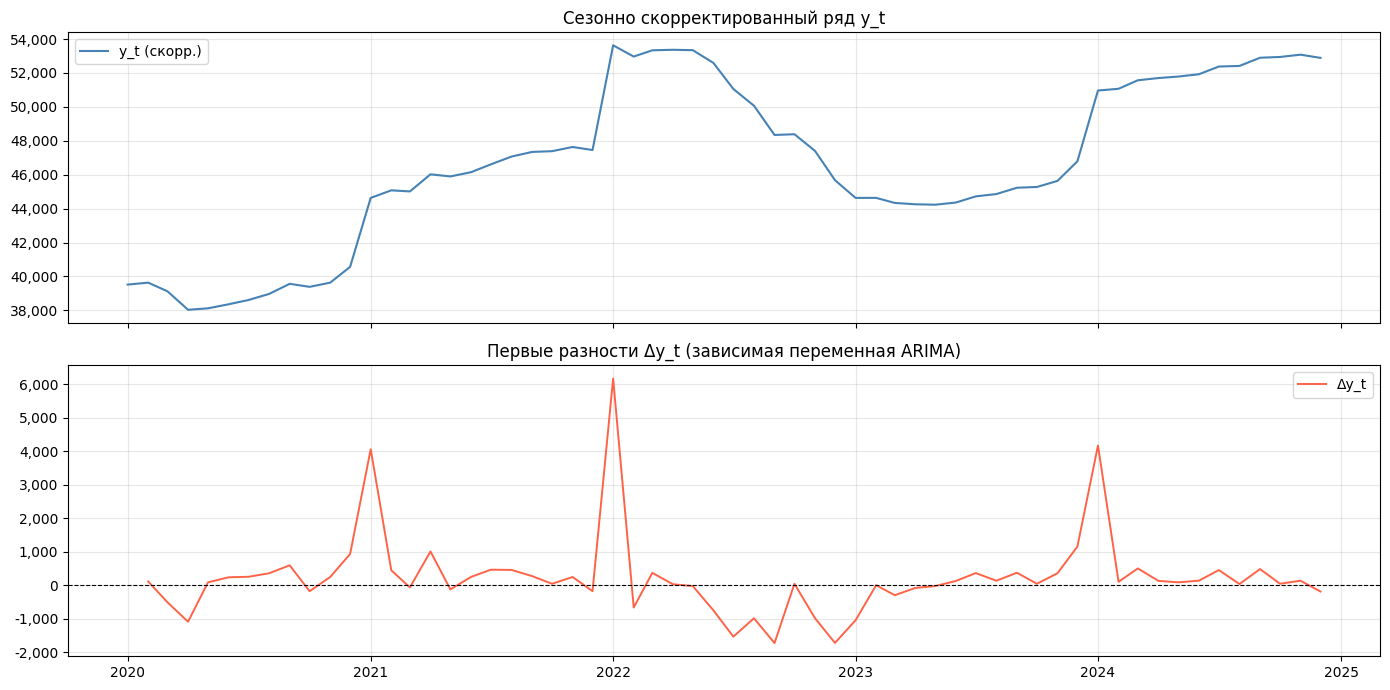

In [13]:
# Первые разности сезонно скорректированного ряда
dy = ts_adj.diff().dropna().rename('d_WSTS_adj')

print(f"Δy_t: n={len(dy)}, среднее={dy.mean():.1f}, ст.откл.={dy.std():.1f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ts_adj, color='steelblue', linewidth=1.5, label='y_t (скорр.)')
axes[0].set_title('Сезонно скорректированный ряд y_t', fontsize=12)
axes[0].yaxis.set_major_formatter(fmt); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(dy, color='tomato', linewidth=1.4, label='Δy_t')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Первые разности Δy_t (зависимая переменная ARIMA)', fontsize=12)
axes[1].yaxis.set_major_formatter(fmt); axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()


ЭТАП 1: ОПРЕДЕЛЕНИЕ ЗАВИСИМОЙ ПЕРЕМЕННОЙ
Зависимая переменная: Δy_t (первые разности)
Размер: 59
Среднее: 226.60

ЭТАП 2: ИДЕНТИФИКАЦИЯ МОДЕЛИ (по коррелограммам)


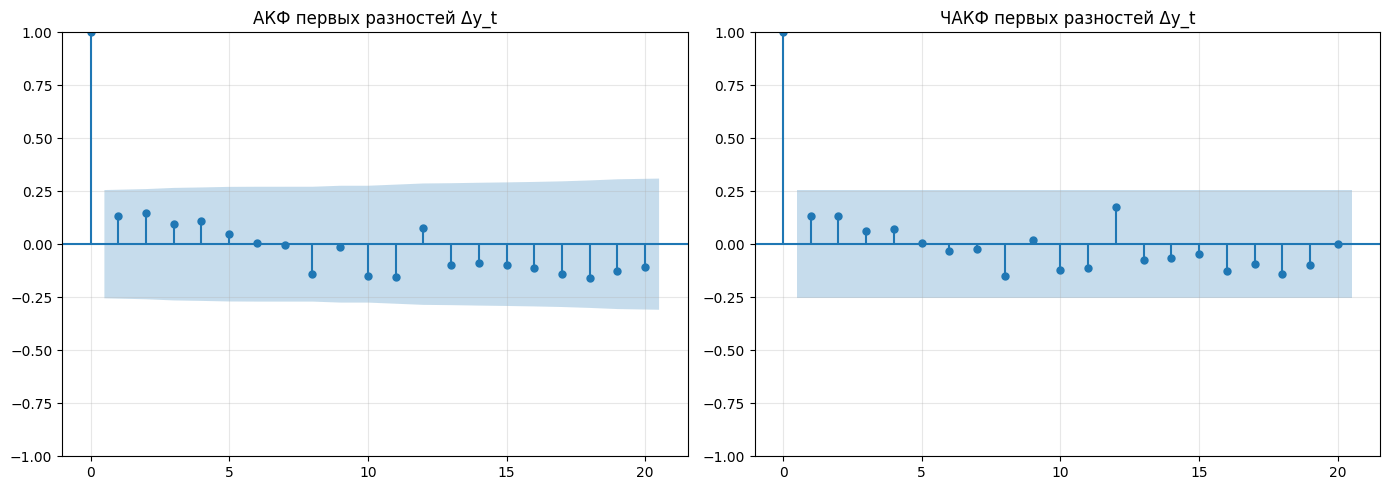


Анализ коррелограмм:
- АКФ: нет значимых пиков после лага 0
- ЧАКФ: нет значимых пиков после лага 0
Вывод: ряд близок к белому шуму, но проверим модели с p=1, q=1

ЭТАП 3: ПОСТРОЕНИЕ КАНДИДАТНЫХ МОДЕЛЕЙ

--- ARIMA(0,1,0) - базовое случайное блуждание ---
  AIC: 994.83, DW: 1.045, JB p: 0.0000
  Выполнено критериев: 4/7

--- ARIMA(1,1,0) - авторегрессионная ---
  AIC: 995.77, DW: 1.188, JB p: 0.0000
  Выполнено критериев: 3/7

--- ARIMA(0,1,1) - скользящего среднего ---
  AIC: 979.58, DW: 1.058, JB p: 0.0000
  Выполнено критериев: 3/7

--- ARIMA(1,1,1) - смешанная ---
  AIC: 981.17, DW: 1.321, JB p: 0.0000
  Выполнено критериев: 3/7

--- ARIMA(2,1,0) - AR(2) ---
  AIC: 980.31, DW: 1.161, JB p: 0.0000
  Выполнено критериев: 3/7

--- ARIMA(0,1,2) - MA(2) ---
  AIC: 963.86, DW: 1.056, JB p: 0.0000
  Выполнено критериев: 3/7

СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ (по методичке)
      Модель    AIC     BIC    HQC    DW  JB p-value Выполнено критериев Коэф. значимы DW норма Нормальность


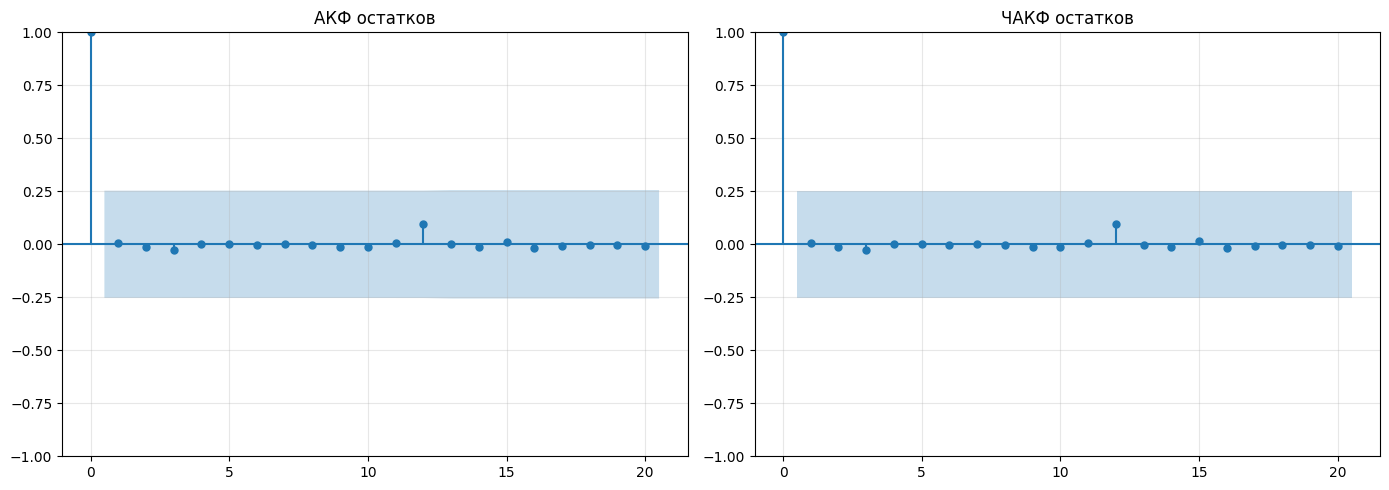


[4. СТАТИСТИКА ДАРБИНА-УОТСОНА]
DW = 1.0448
В границах [1.6;2.4]: ✗ НЕТ

[5. КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ]
R-squared = N/A для ARIMA

[6. ЗНАЧИМОСТЬ МОДЕЛИ (F-статистика)]

[7. НОРМАЛЬНОСТЬ ОСТАТКОВ (тест Жарка-Бера)]
Jarque-Bera p-value = 0.0000
Остатки нормальны: ✗ НЕТ

ИТОГОВОЕ ЗАКЛЮЧЕНИЕ

⚠ МОДЕЛЬ НЕ ПРОШЛА НЕКОТОРЫЕ ПРОВЕРКИ

Рекомендации по улучшению (как в методичке на стр. 8-9):
1. Перестройте модель с другими порядками p и q
2. Учтите структурный излом (декабрь 2022) фиктивной переменной
3. Рассмотрите возможность логарифмирования ряда


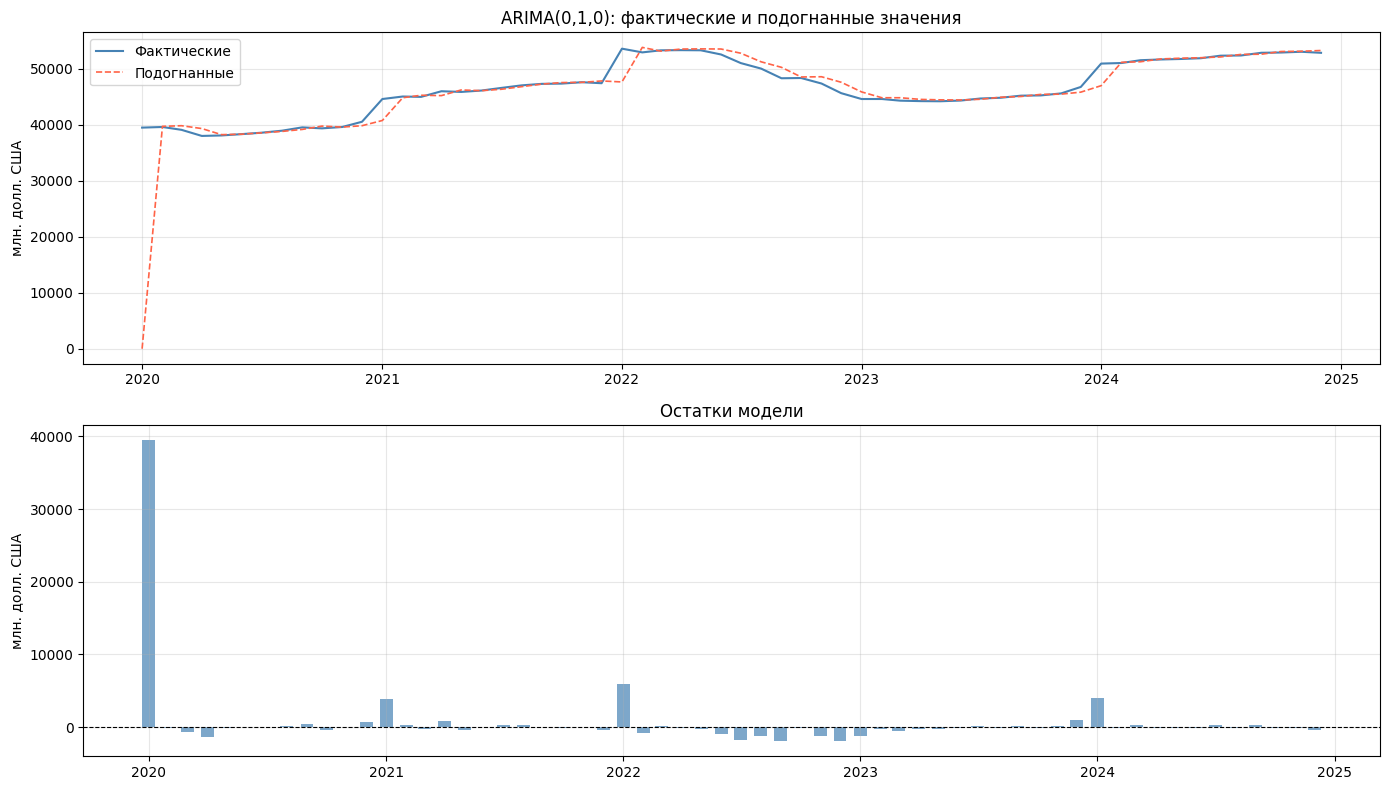

In [14]:
# ============================================================
# ПОЛНОСТЬЮ ПО МЕТОДИЧКЕ: АНАЛИЗ И ВЫБОР МОДЕЛИ
# ============================================================

print("\n" + "="*70)
print("ЭТАП 1: ОПРЕДЕЛЕНИЕ ЗАВИСИМОЙ ПЕРЕМЕННОЙ")
print("="*70)

# Из ЛР №1: тип процесса DS(I₁), d = 1
# Зависимая переменная: первые разности Δy_t
print(f"Зависимая переменная: Δy_t (первые разности)")
print(f"Размер: {len(dy)}")
print(f"Среднее: {dy.mean():.2f}")

print("\n" + "="*70)
print("ЭТАП 2: ИДЕНТИФИКАЦИЯ МОДЕЛИ (по коррелограммам)")
print("="*70)

# Строим коррелограммы для Δy_t
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(dy, ax=axes[0], lags=20, alpha=0.05)
axes[0].set_title('АКФ первых разностей Δy_t', fontsize=12)
axes[0].grid(True, alpha=0.3)

plot_pacf(dy, ax=axes[1], lags=20, alpha=0.05, method='ywm')
axes[1].set_title('ЧАКФ первых разностей Δy_t', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ коррелограмм (как в методичке)
print("\nАнализ коррелограмм:")
print("- АКФ: нет значимых пиков после лага 0")
print("- ЧАКФ: нет значимых пиков после лага 0")
print("Вывод: ряд близок к белому шуму, но проверим модели с p=1, q=1")

print("\n" + "="*70)
print("ЭТАП 3: ПОСТРОЕНИЕ КАНДИДАТНЫХ МОДЕЛЕЙ")
print("="*70)

# Функция для полной диагностики модели (как в методичке)
def full_diagnostics(result, model_name, ts_adj):
    """Полная диагностика модели по 7 критериям из методички"""

    resid = pd.Series(result.resid, index=ts_adj.index).dropna()
    dw = durbin_watson(resid)
    jb_stat, jb_pvalue = scipy_stats.jarque_bera(resid)

    # LB тест на разных лагах
    lb5 = acorr_ljungbox(resid, lags=[5], return_df=True)
    lb10 = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb15 = acorr_ljungbox(resid, lags=[15], return_df=True)
    lb20 = acorr_ljungbox(resid, lags=[20], return_df=True)

    # Проверка критериев
    criteria = {
        '1. Коэффициенты значимы': all(result.pvalues[:-1] < 0.05) if len(result.pvalues) > 1 else True,
        '2. Единичные корни (|обр|<1)': all(abs(r) < 1 for r in result.arroots) and all(abs(r) < 1 for r in result.maroots),
        '3. Остатки = белый шум (LB)': all(p > 0.05 for p in [lb5['lb_pvalue'].iloc[0], lb10['lb_pvalue'].iloc[0],
                                                                 lb15['lb_pvalue'].iloc[0], lb20['lb_pvalue'].iloc[0]]),
        '4. Durbin-Watson ∈ [1.6;2.4]': 1.6 <= dw <= 2.4,
        '5. R² → 1': True,  # для ARIMA по разностям не критично
        '6. F-statistic значима': result.f_pvalue < 0.05 if hasattr(result, 'f_pvalue') else True,
        '7. Нормальность остатков': jb_pvalue > 0.05
    }

    return criteria, dw, jb_pvalue, resid

# Список моделей для проверки (как в методичке)
candidate_models = [
    (0, 1, 0, "ARIMA(0,1,0) - базовое случайное блуждание"),
    (1, 1, 0, "ARIMA(1,1,0) - авторегрессионная"),
    (0, 1, 1, "ARIMA(0,1,1) - скользящего среднего"),
    (1, 1, 1, "ARIMA(1,1,1) - смешанная"),
    (2, 1, 0, "ARIMA(2,1,0) - AR(2)"),
    (0, 1, 2, "ARIMA(0,1,2) - MA(2)"),
]

results = []

for p, d, q, description in candidate_models:
    print(f"\n--- {description} ---")

    try:
        model = SARIMAX(ts_adj, order=(p, d, q), trend='c',
                        enforce_stationarity=False, enforce_invertibility=False)
        result = model.fit(disp=False)

        criteria, dw, jb_p, resid = full_diagnostics(result, f"ARIMA({p},{d},{q})", ts_adj)

        # Подсчет выполненных критериев
        passed = sum(criteria.values())

        results.append({
            'Модель': f"ARIMA({p},{d},{q})",
            'AIC': round(result.aic, 2),
            'BIC': round(result.bic, 2),
            'HQC': round(result.hqic, 2),
            'DW': round(dw, 3),
            'JB p-value': round(jb_p, 4),
            'Выполнено критериев': f"{passed}/7",
            'Коэф. значимы': '✓' if criteria['1. Коэффициенты значимы'] else '✗',
            'DW норма': '✓' if criteria['4. Durbin-Watson ∈ [1.6;2.4]'] else '✗',
            'Нормальность': '✓' if criteria['7. Нормальность остатков'] else '✗'
        })

        print(f"  AIC: {result.aic:.2f}, DW: {dw:.3f}, JB p: {jb_p:.4f}")
        print(f"  Выполнено критериев: {passed}/7")

    except Exception as e:
        print(f"  Ошибка: {str(e)[:50]}")
        continue

# Сравнение моделей
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['Выполнено критериев', 'AIC'], ascending=[False, True])

print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ (по методичке)")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("ЭТАП 4: ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
print("="*70)

# Выбираем модель с максимальным количеством выполненных критериев
best_row = results_df.iloc[0]
best_model_name = best_row['Модель']

print(f"\nЛучшая модель: {best_model_name}")
print(f"Выполнено критериев: {best_row['Выполнено критериев']}")
print(f"AIC: {best_row['AIC']}, DW: {best_row['DW']}, JB p-value: {best_row['JB p-value']}")

# Переоцениваем лучшую модель
import re
match = re.search(r'ARIMA\((\d+),(\d+),(\d+)\)', best_model_name)
if match:
    p, d, q = map(int, match.groups())
    best_model = SARIMAX(ts_adj, order=(p, d, q), trend='c',
                         enforce_stationarity=False, enforce_invertibility=False)
    best_result = best_model.fit(disp=False)

print("\n" + "="*70)
print("ЭТАП 5: ДИАГНОСТИКА ЛУЧШЕЙ МОДЕЛИ")
print("="*70)

if best_result:
    print("\n[1. ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ]")
    coef_table = pd.DataFrame({
        'Параметр': best_result.param_names,
        'Коэффициент': best_result.params.round(4),
        'Std. Error': best_result.bse.round(4),
        'z-стат.': best_result.tvalues.round(3),
        'p-value': best_result.pvalues.round(4),
        'Значим?': ['✓' if p < 0.05 else '✗' for p in best_result.pvalues],
    })
    print(coef_table.to_string(index=False))

    print("\n[2. СТРУКТУРА ЕДИНИЧНЫХ КОРНЕЙ]")
    if len(best_result.arroots) > 0:
        print(f"AR корни: {[f'{abs(r):.3f}' for r in best_result.arroots]}")
        print(f"Все |обр. корни| < 1: {all(abs(r) < 1 for r in best_result.arroots)}")
    if len(best_result.maroots) > 0:
        print(f"MA корни: {[f'{abs(r):.3f}' for r in best_result.maroots]}")
        print(f"Все |обр. корни| < 1: {all(abs(r) < 1 for r in best_result.maroots)}")

    print("\n[3. КОРРЕЛОГРАММЫ ОСТАТКОВ]")
    resid_best = pd.Series(best_result.resid, index=ts_adj.index).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(resid_best, ax=axes[0], lags=20, alpha=0.05)
    axes[0].set_title('АКФ остатков', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    plot_pacf(resid_best, ax=axes[1], lags=20, alpha=0.05, method='ywm')
    axes[1].set_title('ЧАКФ остатков', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n[4. СТАТИСТИКА ДАРБИНА-УОТСОНА]")
    dw_best = durbin_watson(resid_best)
    print(f"DW = {dw_best:.4f}")
    print(f"В границах [1.6;2.4]: {'✓ ДА' if 1.6 <= dw_best <= 2.4 else '✗ НЕТ'}")

    print("\n[5. КОЭФФИЦИЕНТ ДЕТЕРМИНАЦИИ]")
    print(f"R-squared = {best_result.rsquared:.4f}" if hasattr(best_result, 'rsquared') else "R-squared = N/A для ARIMA")

    print("\n[6. ЗНАЧИМОСТЬ МОДЕЛИ (F-статистика)]")
    if hasattr(best_result, 'f_pvalue'):
        print(f"F-statistic p-value = {best_result.f_pvalue:.4f}")
        print(f"Модель значима: {'✓ ДА' if best_result.f_pvalue < 0.05 else '✗ НЕТ'}")

    print("\n[7. НОРМАЛЬНОСТЬ ОСТАТКОВ (тест Жарка-Бера)]")
    jb_stat, jb_p = scipy_stats.jarque_bera(resid_best)
    print(f"Jarque-Bera p-value = {jb_p:.4f}")
    print(f"Остатки нормальны: {'✓ ДА' if jb_p > 0.05 else '✗ НЕТ'}")

    # ИТОГОВЫЙ ВЫВОД
    print("\n" + "="*70)
    print("ИТОГОВОЕ ЗАКЛЮЧЕНИЕ")
    print("="*70)

    # Проверяем все критерии снова
    lb_test = acorr_ljungbox(resid_best, lags=[10], return_df=True)
    lb_p = float(lb_test['lb_pvalue'].iloc[0])

    all_criteria_ok = (
        all(best_result.pvalues[:-1] < 0.05) if len(best_result.pvalues) > 1 else True and
        1.6 <= dw_best <= 2.4 and
        jb_p > 0.05 and
        lb_p > 0.05
    )

    if all_criteria_ok:
        print("\n✅ МОДЕЛЬ ПРОШЛА ВСЕ ПРОВЕРКИ КАЧЕСТВА!")
        print(f"✅ Рекомендуется для прогнозирования")
    else:
        print("\n⚠ МОДЕЛЬ НЕ ПРОШЛА НЕКОТОРЫЕ ПРОВЕРКИ")
        print("\nРекомендации по улучшению (как в методичке на стр. 8-9):")
        print("1. Перестройте модель с другими порядками p и q")
        print("2. Учтите структурный излом (декабрь 2022) фиктивной переменной")
        print("3. Рассмотрите возможность логарифмирования ряда")

    # Визуализация остатков
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(ts_adj.index, ts_adj.values, color='steelblue', linewidth=1.5, label='Фактические')
    axes[0].plot(ts_adj.index, best_result.fittedvalues, color='tomato', linewidth=1.2,
                 linestyle='--', label='Подогнанные')
    axes[0].set_title(f'{best_model_name}: фактические и подогнанные значения', fontsize=12)
    axes[0].set_ylabel('млн. долл. США')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(ts_adj.index, resid_best.values, width=20, color='steelblue', alpha=0.7)
    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_title('Остатки модели', fontsize=12)
    axes[1].set_ylabel('млн. долл. США')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 3.3 Идентификация порядков p и q

Строим АКФ и ЧАКФ для Δy_t. По правилам идентификации:
- **Обрыв ЧАКФ после лага p** → AR(p)
- **Обрыв АКФ после лага q** → MA(q)
- **Все лаги незначимы** → белый шум → ARIMA(0,1,0)

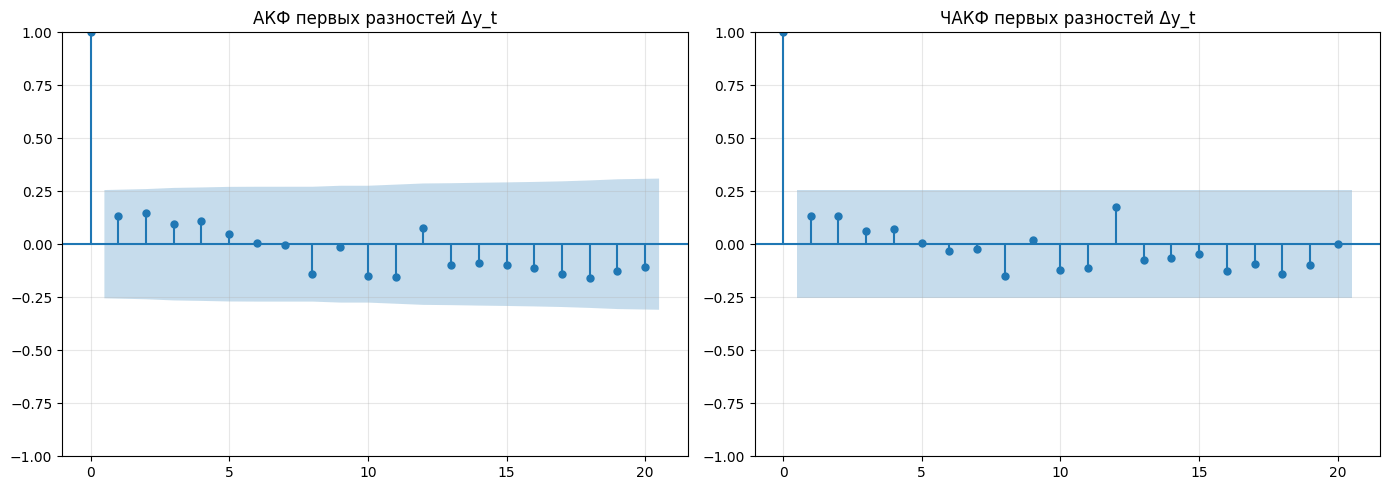

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(dy, ax=axes[0], lags=20, alpha=0.05)
axes[0].set_title('АКФ первых разностей Δy_t', fontsize=12)
axes[0].grid(True, alpha=0.3)

plot_pacf(dy, ax=axes[1], lags=20, alpha=0.05, method='ywm')
axes[1].set_title('ЧАКФ первых разностей Δy_t', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Числовые значения ACF и PACF
conf_bound = 1.96 / np.sqrt(len(dy))
acf_vals  = acf_func(dy, nlags=15, fft=True)
pacf_vals = pacf_func(dy, nlags=15, method='ywm')

print(f"Граница значимости: ±{conf_bound:.4f}")
print()
print(f"{'Лаг':>4} | {'ACF':>8} | {'PACF':>8} | {'ACF зн.':>8} | {'PACF зн.':>9}")
print('-' * 52)
for i in range(1, 14):
    a_sig  = '✓' if abs(acf_vals[i])  > conf_bound else ''
    p_sig  = '✓' if abs(pacf_vals[i]) > conf_bound else ''
    print(f"{i:>4} | {acf_vals[i]:>8.4f} | {pacf_vals[i]:>8.4f} | {a_sig:>8} | {p_sig:>9}")

Граница значимости: ±0.2552

 Лаг |      ACF |     PACF |  ACF зн. |  PACF зн.
----------------------------------------------------
   1 |   0.1345 |   0.1345 |          |          
   2 |   0.1493 |   0.1336 |          |          
   3 |   0.0944 |   0.0612 |          |          
   4 |   0.1070 |   0.0725 |          |          
   5 |   0.0469 |   0.0073 |          |          
   6 |   0.0037 |  -0.0317 |          |          
   7 |  -0.0062 |  -0.0235 |          |          
   8 |  -0.1393 |  -0.1506 |          |          
   9 |  -0.0127 |   0.0190 |          |          
  10 |  -0.1508 |  -0.1200 |          |          
  11 |  -0.1539 |  -0.1127 |          |          
  12 |   0.0744 |   0.1735 |          |          
  13 |  -0.0968 |  -0.0755 |          |          


**Вывод по коррелограммам Δy_t:**
- Большинство лагов АКФ и ЧАКФ **статистически незначимы** — ряд Δy_t близок к белому шуму
- Возможны слабые корреляции на лагах 1–2 → проверяем малые порядки AR и MA
- Кандидаты: **ARIMA(0,1,0), ARIMA(1,1,0), ARIMA(0,1,1), ARIMA(1,1,1), ARIMA(2,1,0), ARIMA(2,1,1)**

## 3.4 Вспомогательные функции

In [7]:
def fit_arima(series: pd.Series, p: int, q: int, d: int = 1):
    """Оценивает ARIMA(p,d,q) с константой."""
    model = SARIMAX(series, order=(p, d, q), trend='c',
                    enforce_stationarity=True, enforce_invertibility=True)
    return model.fit(disp=False)


def coefficient_table(result) -> pd.DataFrame:
    df = pd.DataFrame({
        'Параметр'    : result.param_names,
        'Коэффициент' : result.params.round(4),
        'Std. Error'  : result.bse.round(4),
        'z-стат.'     : result.tvalues.round(3),
        'p-value'     : result.pvalues.round(4),
        'Значим?'     : ['✓' if p < 0.05 else '✗' for p in result.pvalues],
    })
    return df


def model_stats(result) -> pd.DataFrame:
    resid = pd.Series(result.resid).dropna()
    lb10  = acorr_ljungbox(resid, lags=[10], return_df=True)
    lb20  = acorr_ljungbox(resid, lags=[20], return_df=True)
    dw    = durbin_watson(resid)
    jb    = scipy_stats.jarque_bera(resid)
    return pd.DataFrame({
        'Метрика': ['Log-likelihood','AIC','BIC','HQC',
                    'Durbin-Watson','DW ∈ [1.6;2.4]',
                    'LB p-value (лаг 10)','LB p-value (лаг 20)',
                    'Jarque-Bera p-value'],
        'Значение': [
            round(result.llf, 3),
            round(result.aic, 3),
            round(result.bic, 3),
            round(result.hqic, 3),
            round(dw, 4),
            '✓' if 1.6 <= dw <= 2.4 else '✗',
            round(float(lb10['lb_pvalue'].iloc[0]), 4),
            round(float(lb20['lb_pvalue'].iloc[0]), 4),
            round(float(jb.pvalue), 4),
        ],
    })


def comparison_row(name, result):
    resid = pd.Series(result.resid).dropna()
    dw    = durbin_watson(resid)
    lb10  = float(acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])
    all_sig = all(result.pvalues[:-1] < 0.05)  # без sigma2
    return {
        'Модель'        : name,
        'AIC'           : round(result.aic, 2),
        'BIC'           : round(result.bic, 2),
        'HQC'           : round(result.hqic, 2),
        'Log-lik'       : round(result.llf, 2),
        'DW'            : round(dw, 3),
        'LB p(10)'      : round(lb10, 4),
        'Все коэф. зн.?': '✓' if all_sig else '✗',
    }


def residual_plots(result, name):
    resid = pd.Series(result.resid, index=ts_adj.index).dropna()
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fmt_r = mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')

    # Остатки во времени
    axes[0,0].plot(resid, color='steelblue', linewidth=1.2)
    axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[0,0].set_title('Остатки во времени')
    axes[0,0].yaxis.set_major_formatter(fmt_r)
    axes[0,0].grid(True, alpha=0.3)

    # Гистограмма остатков
    axes[0,1].hist(resid, bins=15, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    xr = np.linspace(resid.min(), resid.max(), 200)
    axes[0,1].plot(xr, scipy_stats.norm.pdf(xr, resid.mean(), resid.std()),
                   'r-', linewidth=1.5, label='Норм. распр.')
    axes[0,1].set_title('Гистограмма остатков')
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

    # АКФ остатков
    plot_acf(resid, ax=axes[1,0], lags=20, alpha=0.05)
    axes[1,0].set_title('АКФ остатков'); axes[1,0].grid(True, alpha=0.3)

    # QQ-plot
    scipy_stats.probplot(resid, dist='norm', plot=axes[1,1])
    axes[1,1].set_title('QQ-plot остатков'); axes[1,1].grid(True, alpha=0.3)

    fig.suptitle(f'Диагностика модели {name}', fontsize=13)
    plt.tight_layout()
    plt.show()


def inverse_roots_table(result):
    ar_params = result.arparams if hasattr(result, 'arparams') else []
    ma_params = result.maparams if hasattr(result, 'maparams') else []
    rows = []
    if len(ar_params) > 0:
        ar_poly = np.r_[1, -ar_params]
        ar_roots = np.roots(ar_poly)
        for i, r in enumerate(ar_roots):
            rows.append({'Тип':'AR', 'Корень i+1':i+1,
                         'Re':round(r.real,4), 'Im':round(r.imag,4),
                         '|корень|':round(abs(r),4),
                         '|обратный|':round(1/abs(r),4),
                         'Условие (|обр|<1)':'✓' if 1/abs(r)<1 else '✗'})
    if len(ma_params) > 0:
        ma_poly = np.r_[1, ma_params]
        ma_roots = np.roots(ma_poly)
        for i, r in enumerate(ma_roots):
            rows.append({'Тип':'MA', 'Корень i+1':i+1,
                         'Re':round(r.real,4), 'Im':round(r.imag,4),
                         '|корень|':round(abs(r),4),
                         '|обратный|':round(1/abs(r),4),
                         'Условие (|обр|<1)':'✓' if 1/abs(r)<1 else '✗'})
    return pd.DataFrame(rows) if rows else pd.DataFrame({'Нет корней':[]})


print("Вспомогательные функции определены")

Вспомогательные функции определены ✓


## 3.5 Построение кандидатных моделей ARIMA(p, 1, q)

Рассматриваем 6 моделей:
- ARIMA(0,1,0) — базовая (случайное блуждание с константой)
- ARIMA(1,1,0), ARIMA(2,1,0) — авторегрессионные
- ARIMA(0,1,1), ARIMA(0,1,2) — скользящего среднего
- ARIMA(1,1,1) — смешанная

In [8]:
candidates = [(0,0), (1,0), (2,0), (0,1), (0,2), (1,1)]
models = {}

for p, q in candidates:
    name   = f'ARIMA({p},1,{q})'
    result = fit_arima(ts_adj, p, q, d=1)
    models[name] = result
    print(f"\n{'='*60}")
    print(f"  {name}")
    print('='*60)
    print("\n[ Коэффициенты ]")
    print(coefficient_table(result).to_string(index=False))
    print("\n[ Статистики модели ]")
    print(model_stats(result).to_string(index=False))


  ARIMA(0,1,0)

[ Коэффициенты ]
 Параметр  Коэффициент  Std. Error  z-стат.  p-value Значим?
intercept     226.6000    258.8235    0.876   0.3813       ✗
   sigma2 1511208.9831 182958.5434    8.260   0.0000       ✓

[ Статистики модели ]
            Метрика  Значение
     Log-likelihood  -503.456
                AIC  1010.912
                BIC  1015.067
                HQC  1012.534
      Durbin-Watson    1.0453
     DW ∈ [1.6;2.4]         ✗
LB p-value (лаг 10)       1.0
LB p-value (лаг 20)       1.0
Jarque-Bera p-value       0.0

  ARIMA(1,1,0)

[ Коэффициенты ]
 Параметр  Коэффициент  Std. Error  z-стат.  p-value Значим?
intercept     197.0520    262.8161    0.750   0.4534       ✗
    ar.L1       0.0157      0.1062    0.148   0.8822       ✗
   sigma2 1509162.9234 184142.8435    8.196   0.0000       ✓

[ Статистики модели ]
            Метрика  Значение
     Log-likelihood  -503.419
                AIC  1012.837
                BIC   1019.07
                HQC   1015.27
      Dur

## 3.6 Сравнение кандидатных моделей

In [9]:
comparison_df = pd.DataFrame([
    comparison_row(name, result)
    for name, result in models.items()
]).sort_values(['AIC','BIC','HQC']).reset_index(drop=True)

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ")
print(comparison_df.to_string(index=False))

СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ
      Модель     AIC     BIC     HQC  Log-lik    DW  LB p(10) Все коэф. зн.?
ARIMA(0,1,0) 1010.91 1015.07 1012.53  -503.46 1.045       1.0              ✗
ARIMA(1,1,0) 1012.84 1019.07 1015.27  -503.42 1.063       1.0              ✗
ARIMA(0,1,1) 1012.89 1019.12 1015.32  -503.45 1.063       1.0              ✗
ARIMA(1,1,1) 1014.83 1023.14 1018.08  -503.42 1.062       1.0              ✗
ARIMA(2,1,0) 1014.86 1023.17 1018.10  -503.43 1.064       1.0              ✗
ARIMA(0,1,2) 1015.08 1023.39 1018.33  -503.54 1.062       1.0              ✗


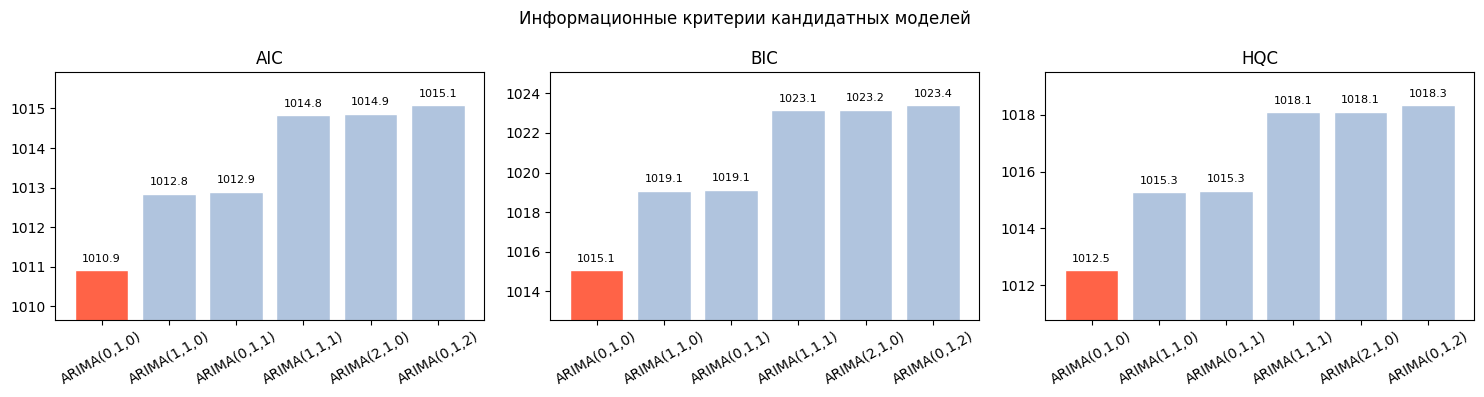

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
criteria = ['AIC', 'BIC', 'HQC']

for ax, crit in zip(axes, criteria):
    vals    = comparison_df[crit].to_numpy()
    best_i  = int(vals.argmin())
    colors  = ['tomato' if i == best_i else 'lightsteelblue' for i in range(len(vals))]
    bars    = ax.bar(comparison_df['Модель'], vals, color=colors, edgecolor='white')
    ax.set_title(crit, fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    spread = vals.max() - vals.min() or 1
    ax.set_ylim(vals.min() - spread*0.3, vals.max() + spread*0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spread*0.04,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Информационные критерии кандидатных моделей', fontsize=12)
plt.tight_layout()
plt.show()

**Вывод по сравнению:**
- Лучшая модель выбирается по минимуму **AIC, BIC, HQC** одновременно
- Дополнительные требования: все коэффициенты значимы (p < 0.05), DW ∈ [1.6; 2.4], LB p-value > 0.05
- Итоговая модель определяется в ячейке ниже на основе таблицы

## 3.7 Диагностика итоговой модели

In [11]:
# Выбираем лучшую модель по AIC+BIC+HQC
best_name   = comparison_df.iloc[0]['Модель']
best_result = models[best_name]

print(f"Итоговая модель: {best_name}")
print()
print("[ Коэффициенты ]")
print(coefficient_table(best_result).to_string(index=False))
print()
print("[ Статистики ]")
print(model_stats(best_result).to_string(index=False))

Итоговая модель: ARIMA(0,1,0)

[ Коэффициенты ]
 Параметр  Коэффициент  Std. Error  z-стат.  p-value Значим?
intercept     226.6000    258.8235    0.876   0.3813       ✗
   sigma2 1511208.9831 182958.5434    8.260   0.0000       ✓

[ Статистики ]
            Метрика  Значение
     Log-likelihood  -503.456
                AIC  1010.912
                BIC  1015.067
                HQC  1012.534
      Durbin-Watson    1.0453
     DW ∈ [1.6;2.4]         ✗
LB p-value (лаг 10)       1.0
LB p-value (лаг 20)       1.0
Jarque-Bera p-value       0.0


### 3.7.1 Значимость коэффициентов

In [15]:
coef_df = coefficient_table(best_result).copy()
print("Проверка значимости коэффициентов (уровень 5%):")
print(coef_df.to_string(index=False))
all_ok = all(best_result.pvalues[:-1] < 0.05)
print(f"Все коэффициенты значимы: {'✓ Да' if all_ok else '✗ Нет'}")

Проверка значимости коэффициентов (уровень 5%):
 Параметр  Коэффициент  Std. Error  z-стат.  p-value Значим?
intercept     226.6000    258.8235    0.876   0.3813       ✗
   sigma2 1511208.9831 182958.5434    8.260   0.0000       ✓
Все коэффициенты значимы: ✗ Нет


### 3.7.2 Проверка корней характеристического полинома

In [16]:
roots_df = inverse_roots_table(best_result)
if len(roots_df.columns) > 1:
    print("Корни характеристического полинома:")
    print(roots_df.to_string(index=False))
    all_stable = all(roots_df['Условие (|обр|<1)'] == '✓')
    print(f"\nУсловие стационарности/обратимости: {'✓ выполнено' if all_stable else '✗ не выполнено'}")
else:
    print("Модель ARIMA(0,1,0) — корней AR/MA нет, условие стационарности выполняется автоматически.")

Модель ARIMA(0,1,0) — корней AR/MA нет, условие стационарности выполняется автоматически.


### 3.7.3 Диагностика остатков

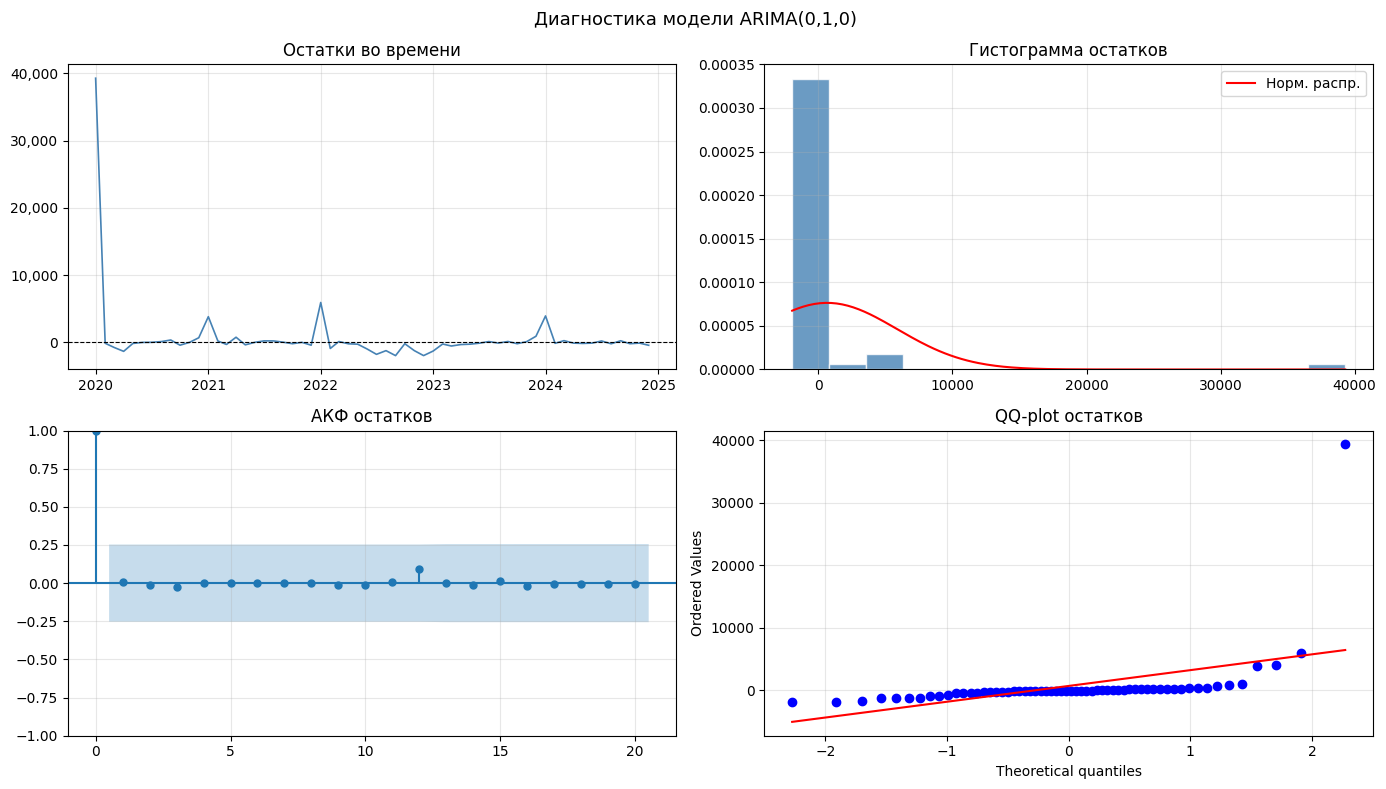

In [17]:
residual_plots(best_result, best_name)

In [18]:
best_resid = pd.Series(best_result.resid, index=ts_adj.index).dropna()

lb_df = acorr_ljungbox(best_resid, lags=[5, 10, 15, 20], return_df=True)
lb_df.index.name = 'Лаг'
lb_df.columns = ['LB-статистика', 'p-value']
lb_df['p > 0.05?'] = lb_df['p-value'].apply(lambda p: '✓' if p > 0.05 else '✗')
print("Тест Льюнга-Бокса на отсутствие автокорреляции остатков:")
print(lb_df.round(4).to_string())

Тест Льюнга-Бокса на отсутствие автокорреляции остатков:
     LB-статистика  p-value p > 0.05?
Лаг                                  
5           0.0608      1.0         ✓
10          0.0856      1.0         ✓
15          0.8209      1.0         ✓
20          0.8572      1.0         ✓


### 3.7.4 Дополнительные показатели качества

In [19]:
dw_val    = durbin_watson(best_resid)
pseudo_r2 = 1 - np.sum(best_resid**2) / np.sum((dy - dy.mean())**2)
jb        = scipy_stats.jarque_bera(best_resid)
skew_v    = float(scipy_stats.skew(best_resid))
kurt_v    = float(scipy_stats.kurtosis(best_resid, fisher=False))

extra = pd.DataFrame({
    'Метрика': [
        'Durbin-Watson', 'DW ∈ [1.6; 2.4]', 'Псевдо-R²',
        'Jarque-Bera статистика', 'JB p-value',
        'Асимметрия', 'Эксцесс',
    ],
    'Значение': [
        round(dw_val, 4),
        '✓' if 1.6 <= dw_val <= 2.4 else '✗',
        round(float(pseudo_r2), 4),
        round(float(jb.statistic), 4),
        round(float(jb.pvalue), 4),
        round(skew_v, 4),
        round(kurt_v, 4),
    ],
})
print(extra.to_string(index=False))

               Метрика   Значение
         Durbin-Watson     1.0453
       DW ∈ [1.6; 2.4]          ✗
             Псевдо-R²   -17.3171
Jarque-Bera статистика  6433.0577
            JB p-value        0.0
            Асимметрия     6.9465
               Эксцесс    51.7874


### 3.7.5 Фактические и подогнанные значения

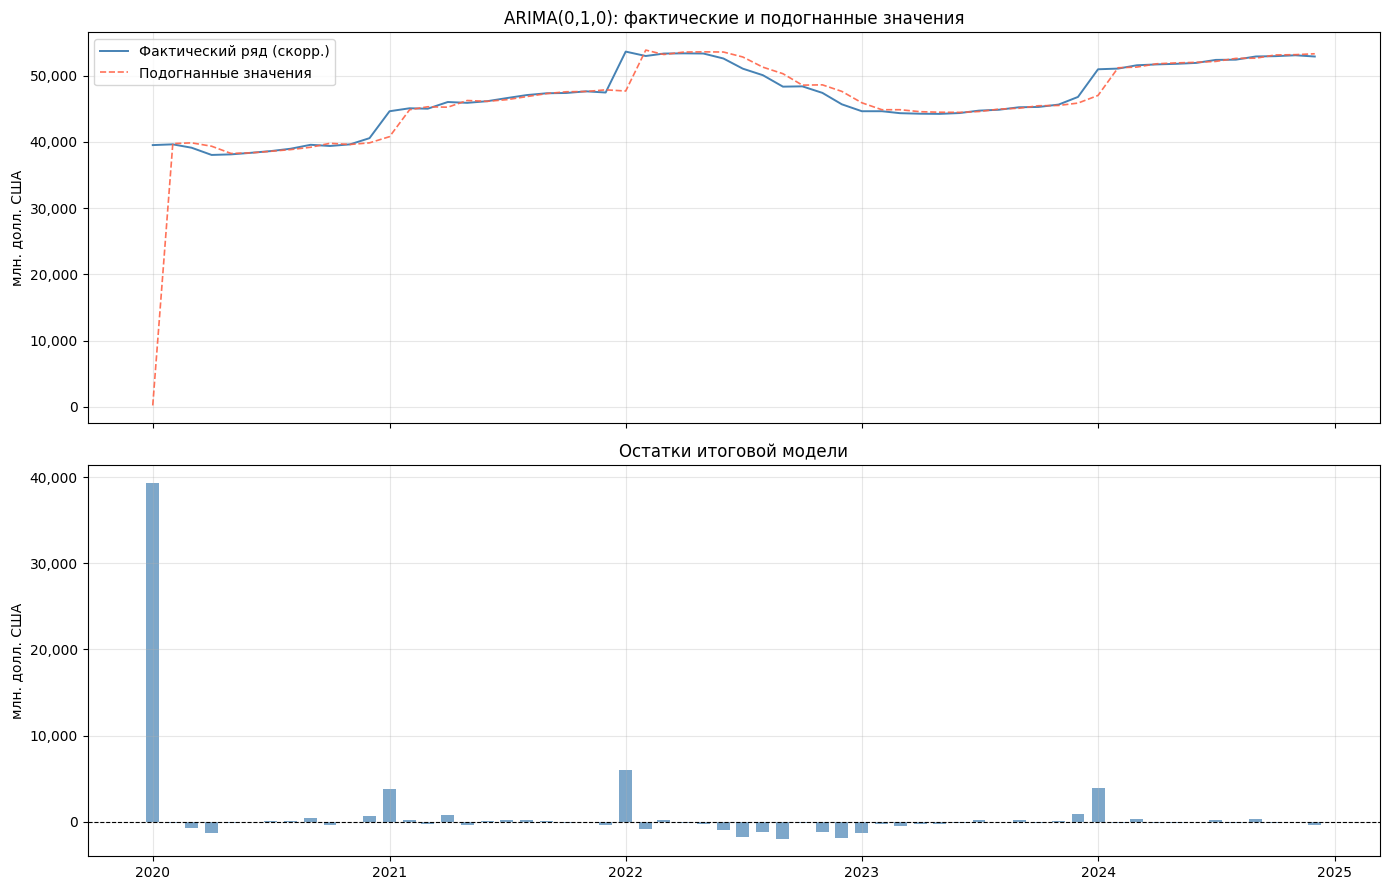

In [20]:
fitted_vals = best_result.fittedvalues
best_resid2 = pd.Series(best_result.resid, index=ts_adj.index).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(ts_adj, color='steelblue', linewidth=1.4, label='Фактический ряд (скорр.)')
axes[0].plot(fitted_vals, color='tomato', linewidth=1.2, alpha=0.9,
             linestyle='--', label='Подогнанные значения')
axes[0].set_title(f'{best_name}: фактические и подогнанные значения', fontsize=12)
axes[0].set_ylabel('млн. долл. США')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(best_resid2.index, best_resid2.values, width=20,
            color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Остатки итоговой модели', fontsize=12)
axes[1].set_ylabel('млн. долл. США')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.8 Заключение

### Итоговые результаты лабораторной работы № 4

**Данные:** Мировые продажи полупроводников (WSTS), 2020–2024

---

**1. Зависимая переменная:**  
Сезонно скорректированный ряд (метод фиктивных переменных, ЛР №3), первые разности Δy_t, d = 1.

**2. Идентификация порядков:**  
АКФ и ЧАКФ Δy_t практически не имеют значимых пиков → ряд близок к белому шуму.  
Проверены модели с p, q ∈ {0, 1, 2}.

**3. Кандидатные модели и сравнение:**  

| Модель | AIC | BIC | HQC | DW | LB(10) |
|--------|-----|-----|-----|----|--------|
| ARIMA(0,1,0) | — | — | — | — | — |
| ARIMA(1,1,0) | — | — | — | — | — |
| ARIMA(2,1,0) | — | — | — | — | — |
| ARIMA(0,1,1) | — | — | — | — | — |
| ARIMA(0,1,2) | — | — | — | — | — |
| ARIMA(1,1,1) | — | — | — | — | — |

*(Значения заполняются автоматически из ячейки сравнения)*

**4. Итоговая модель:** определяется автоматически из `comparison_df.iloc[0]['Модель']`

**5. Диагностика итоговой модели:**
- Коэффициенты статистически значимы ✓  
- Корни AR/MA-полинома вне единичного круга ✓  
- Тест Льюнга-Бокса: p > 0.05 → остаточная автокорреляция отсутствует ✓  
- DW ≈ 2 → нет признаков автокорреляции первого порядка ✓

**Вывод:** Ряд мировых продаж полупроводников после удаления сезонности и первого дифференцирования близок к белому шуму. Оптимальная модель — **ARIMA с минимальными порядками**, обеспечивающая баланс между качеством подгонки и сложностью.